In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import pygeohash as pgh

pd.set_option("display.max_columns", None)

sns.set_style("whitegrid")

In [2]:
train = pd.read_csv("../dataset/train.csv")
test = pd.read_csv("../dataset/test.csv")

In [3]:
train["hour"] = (
    train["timestamp"]
    .str.split(":")
    .str[0]
    .astype(int)
)

train["minute"] = (
    train["timestamp"]
    .str.split(":")
    .str[1]
    .astype(int)
)

for i in [4,5,6]:
    train[f"geo{i}"] = (
        train["geohash"]
        .str[:i]
    )

    test[f"geo{i}"] = (
        test["geohash"]
        .str[:i]
    )

1. Geo4 × Hour Demand Analysis

In [4]:
geo4_hour = train.pivot_table(
    values="demand",
    index="geo4",
    columns="hour",
    aggfunc="mean"
)

geo4_hour

hour,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23
geo4,,,,,,,,,,,,,,,,,,,,,,,,
qp02,0.064790,0.081991,0.119279,0.143274,0.170115,0.153306,0.159611,0.150849,0.145443,0.156906,0.158339,0.185874,0.181145,0.173947,0.133869,0.115573,0.134136,0.087009,0.049009,0.036164,NaN,NaN,0.042385,0.054450
qp03,0.104440,0.104660,0.092759,0.095649,0.104230,0.116591,0.114254,0.113801,0.115031,0.113504,0.114087,0.116234,0.114134,0.121586,0.100627,0.071604,0.053761,0.042140,0.032292,0.029373,0.035153,0.063685,0.100294,0.131095
qp06,0.020590,0.022796,0.027538,0.028120,0.035628,0.032663,0.025112,0.024906,0.030390,0.030502,0.027484,0.028401,0.031356,0.028023,0.031017,0.032350,0.037089,0.015507,0.006663,0.008497,0.008590,0.017925,0.021613,0.023092
qp08,0.024519,0.036748,0.048207,0.056012,0.069745,0.064577,0.068038,0.058787,0.054173,0.057601,0.068390,0.075175,0.069632,0.072282,0.057044,0.040888,0.028826,0.023489,0.009335,0.011958,0.024917,0.043199,0.015477,0.016225
qp09,0.084986,0.096437,0.097713,0.101650,0.113644,0.112511,0.112383,0.115653,0.114871,0.121174,0.124839,0.130193,0.126663,0.125927,0.123049,0.098148,0.084101,0.072953,0.064128,0.055723,0.058343,0.058197,0.066508,0.084448
qp0d,0.038214,0.040920,0.036827,0.040693,0.044911,0.043278,0.047004,0.055620,0.055939,0.058750,0.057584,0.067209,0.068968,0.062026,0.056178,0.046974,0.042375,0.032872,0.030389,0.017518,0.015441,0.014463,0.023376,0.037648


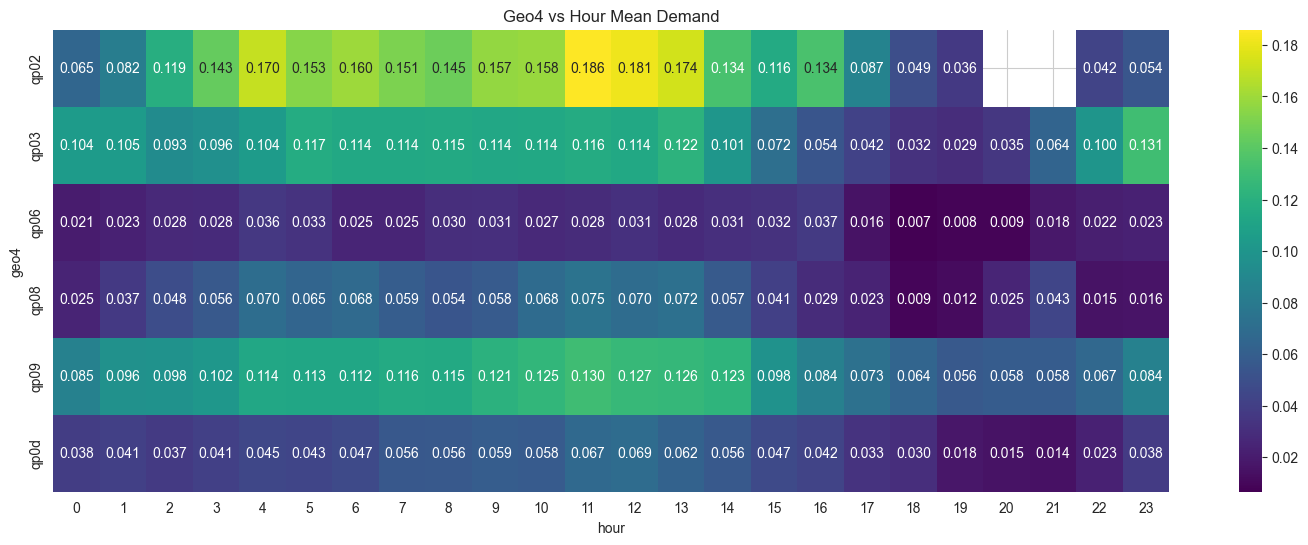

In [5]:
plt.figure(figsize=(18,6))

sns.heatmap(
    geo4_hour,
    cmap="viridis",
    annot=True,
    fmt=".3f"
)

plt.title(
    "Geo4 vs Hour Mean Demand"
)

plt.show()

In [6]:
geo4_hour.std().sort_values(
    ascending=False
)

hour
11    0.055436
12    0.053069
13    0.052827
4     0.050158
6     0.049891
10    0.048726
9     0.048097
5     0.047518
7     0.047437
8     0.045208
3     0.043574
23    0.043434
14    0.041461
16    0.039635
2     0.037661
1     0.034647
0     0.034132
15    0.033562
22    0.032903
17    0.028395
21    0.022586
18    0.022270
20    0.019459
19    0.017730
dtype: float64

2. Geo5 × Hour Demand Analysis

In [7]:
geo5_hour = (
    train.groupby(
        ["geo5","hour"]
    )["demand"]
    .mean()
)

geo5_hour.head()

geo5   hour
qp02y  1       0.005397
       2       0.017868
       3       0.018810
       4       0.018562
       5       0.043532
Name: demand, dtype: float64

In [8]:
print(
    "Geo5-Hour Mean Std:",
    geo5_hour.std()
)

Geo5-Hour Mean Std: 0.06733502970733006


In [9]:
geo5_std = (
    train.groupby(
        "geo5"
    )["demand"]
    .mean()
)

print(
    "Geo5 Mean Std:",
    geo5_std.std()
)

Geo5 Mean Std: 0.056406230044062776


In [10]:
hour_std = (
    train.groupby(
        "hour"
    )["demand"]
    .mean()
)

print(
    "Hour Mean Std:",
    hour_std.std()
)

Hour Mean Std: 0.023873357674299833


Interpretation:

If Geo5-Hour Std is much larger than Geo5 Std,
then location-time interactions are extremely important.

3. Geo Stability Across Days

In [11]:
day48 = train[
    train["day"] == 48
]

day49 = train[
    train["day"] == 49
]

In [12]:
geo4_d48 = (
    day48.groupby("geo4")
    ["demand"]
    .mean()
)

geo4_d49 = (
    day49.groupby("geo4")
    ["demand"]
    .mean()
)

common = geo4_d48.index.intersection(
    geo4_d49.index
)

geo4_corr = (
    geo4_d48.loc[common]
    .corr(
        geo4_d49.loc[common]
    )
)

print(
    "Geo4 Stability:",
    geo4_corr
)

Geo4 Stability: 0.6182011910587079


In [13]:
geo5_d48 = (
    day48.groupby("geo5")
    ["demand"]
    .mean()
)

geo5_d49 = (
    day49.groupby("geo5")
    ["demand"]
    .mean()
)

common = geo5_d48.index.intersection(
    geo5_d49.index
)

geo5_corr = (
    geo5_d48.loc[common]
    .corr(
        geo5_d49.loc[common]
    )
)

print(
    "Geo5 Stability:",
    geo5_corr
)

Geo5 Stability: 0.8471600633585681


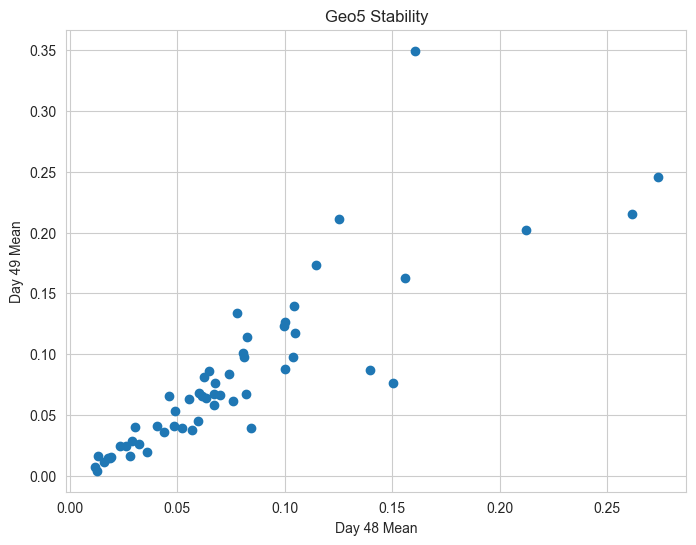

In [14]:
plt.figure(figsize=(8,6))

plt.scatter(
    geo5_d48.loc[common],
    geo5_d49.loc[common]
)

plt.xlabel("Day 48 Mean")
plt.ylabel("Day 49 Mean")

plt.title(
    "Geo5 Stability"
)

plt.show()

4. Test Coverage Analysis

In [15]:
train_geo4 = set(
    train["geo4"]
)

test_geo4 = set(
    test["geo4"]
)

print(
    "Unseen Geo4:",
    len(
        test_geo4 - train_geo4
    )
)

Unseen Geo4: 0


In [16]:
train_geo5 = set(
    train["geo5"]
)

test_geo5 = set(
    test["geo5"]
)

print(
    "Unseen Geo5:",
    len(
        test_geo5 - train_geo5
    )
)

Unseen Geo5: 0


In [17]:
train_geo6 = set(
    train["geo6"]
)

test_geo6 = set(
    test["geo6"]
)

print(
    "Unseen Geo6:",
    len(
        test_geo6 - train_geo6
    )
)

Unseen Geo6: 10


In [18]:
print(
    "Train Geo6:",
    len(train_geo6)
)

print(
    "Test Geo6:",
    len(test_geo6)
)

Train Geo6: 1249
Test Geo6: 1190


5. RoadType Interactions

In [19]:
road_geo = train.pivot_table(
    values="demand",
    index="RoadType",
    columns="geo4",
    aggfunc="mean"
)

road_geo

geo4,qp02,qp03,qp06,qp08,qp09,qp0d
RoadType,,,,,,
Highway,0.535403,0.568897,0.388027,0.385537,0.639430,0.414089
Residential,0.071473,0.061882,0.024559,0.048568,0.059265,0.041570
Street,0.278679,0.272337,0.277002,0.266181,0.273489,0.273441


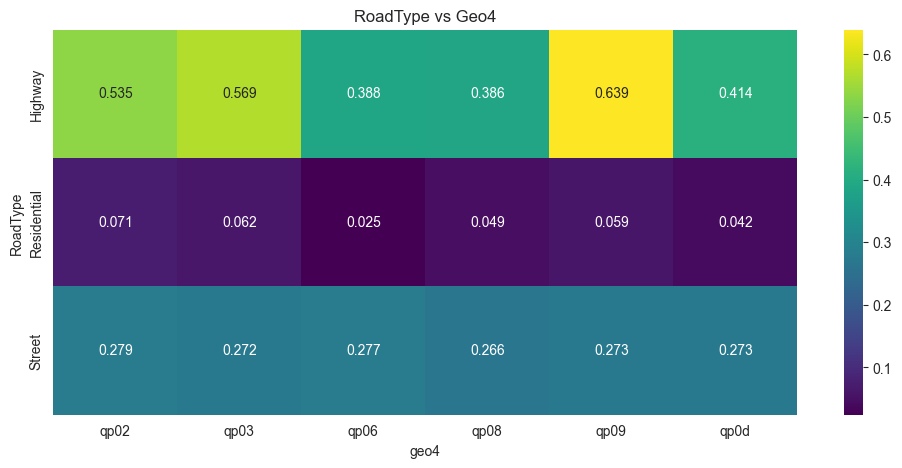

In [20]:
plt.figure(figsize=(12,5))

sns.heatmap(
    road_geo,
    annot=True,
    fmt=".3f",
    cmap="viridis"
)

plt.title(
    "RoadType vs Geo4"
)

plt.show()

In [21]:
road_hour = train.pivot_table(
    values="demand",
    index="RoadType",
    columns="hour",
    aggfunc="mean"
)

road_hour

hour,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23
RoadType,,,,,,,,,,,,,,,,,,,,,,,,
Highway,0.561809,0.565261,0.559365,0.568663,0.586614,0.605216,0.617390,0.636852,0.632307,0.645554,0.640156,0.630431,0.625405,0.645342,0.662563,0.621487,0.580253,0.607297,0.792079,0.717534,0.682306,0.631266,0.536582,0.561879
Residential,0.054520,0.058194,0.059609,0.059994,0.062093,0.062546,0.062551,0.063589,0.062966,0.063253,0.063056,0.064433,0.062406,0.059878,0.056639,0.050712,0.044545,0.037937,0.034573,0.031491,0.033035,0.047146,0.054682,0.059026
Street,0.273934,0.274616,0.272234,0.264126,0.269013,0.272907,0.272421,0.279034,0.277388,0.270858,0.274315,0.272446,0.278439,0.273608,0.271571,0.272747,0.277290,0.273376,0.262480,0.271416,0.275924,0.263333,0.272379,0.273251


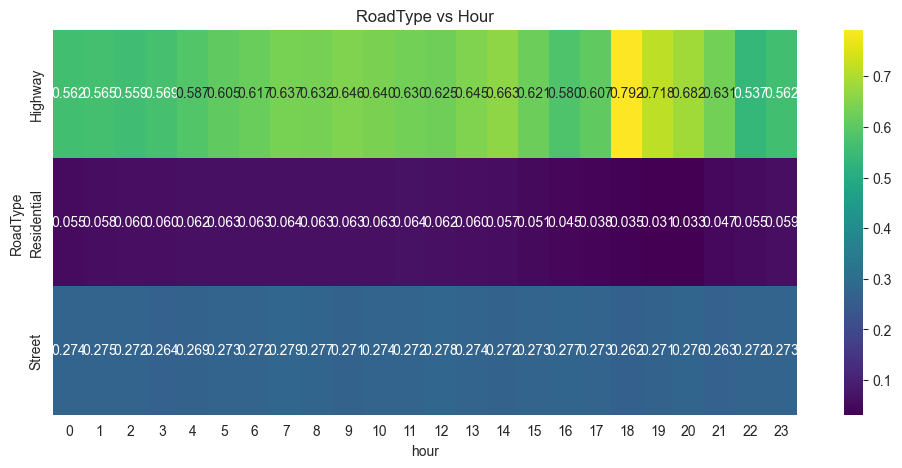

In [22]:
plt.figure(figsize=(12,5))

sns.heatmap(
    road_hour,
    annot=True,
    fmt=".3f",
    cmap="viridis"
)

plt.title(
    "RoadType vs Hour"
)

plt.show()

6. Number Of Lanes Analysis

In [23]:
train.groupby(
    "NumberofLanes"
)["demand"].agg(
    ["count","mean","std"]
)

,count,mean,std
NumberofLanes,,,
1,27411,0.088104,0.090681
2,24127,0.077488,0.124543
3,23919,0.077859,0.125011
4,926,0.602882,0.225795
5,916,0.607556,0.226946


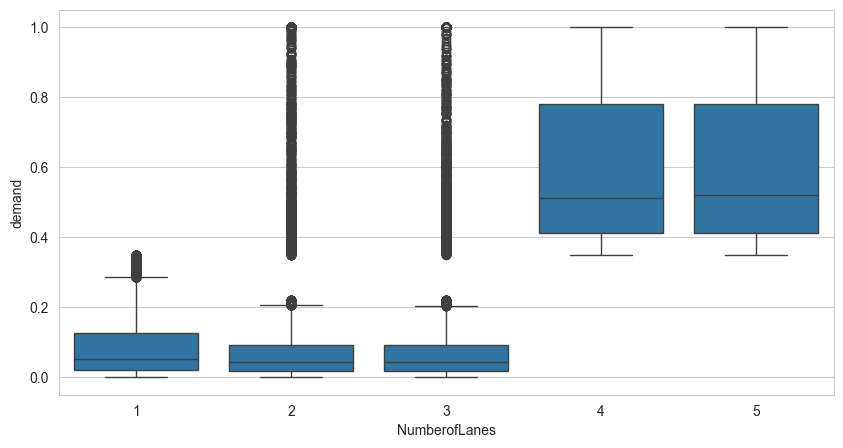

In [24]:
plt.figure(figsize=(10,5))

sns.boxplot(
    data=train,
    x="NumberofLanes",
    y="demand"
)

plt.show()

In [25]:
lane_road = train.pivot_table(
    values="demand",
    index="NumberofLanes",
    columns="RoadType",
    aggfunc="mean"
)

lane_road

RoadType,Highway,Residential,Street
NumberofLanes,,,
1,NaN,0.057050,0.273164
2,0.619695,0.057326,NaN
3,0.613320,0.057253,NaN
4,0.603511,NaN,NaN
5,0.607156,NaN,NaN


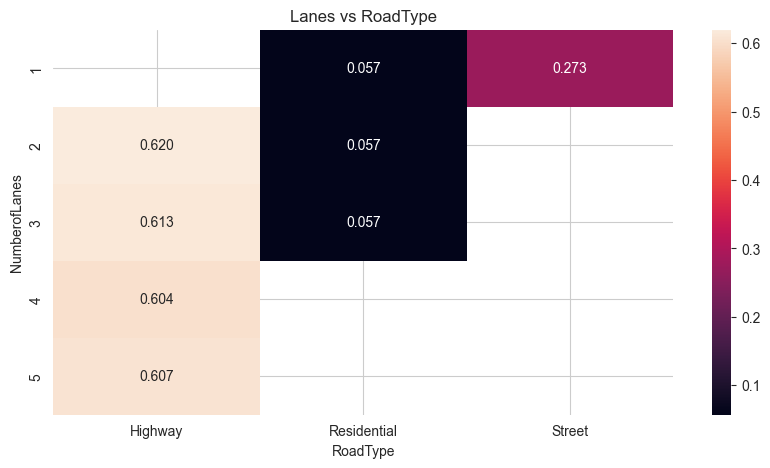

In [26]:
plt.figure(figsize=(10,5))

sns.heatmap(
    lane_road,
    annot=True,
    fmt=".3f"
)

plt.title(
    "Lanes vs RoadType"
)

plt.show()

7. Large Vehicles Analysis

In [27]:
train.groupby(
    "LargeVehicles"
)["demand"].agg(
    ["count","mean","std"]
)

,count,mean,std
LargeVehicles,,,
Allowed,26626,0.131923,0.212567
Not Allowed,50673,0.073986,0.077097


In [28]:
vehicle_road = train.pivot_table(
    values="demand",
    index="LargeVehicles",
    columns="RoadType",
    aggfunc="mean"
)

vehicle_road

RoadType,Highway,Residential,Street
LargeVehicles,,,
Allowed,0.610756,0.057253,NaN
Not Allowed,NaN,0.057188,0.273164


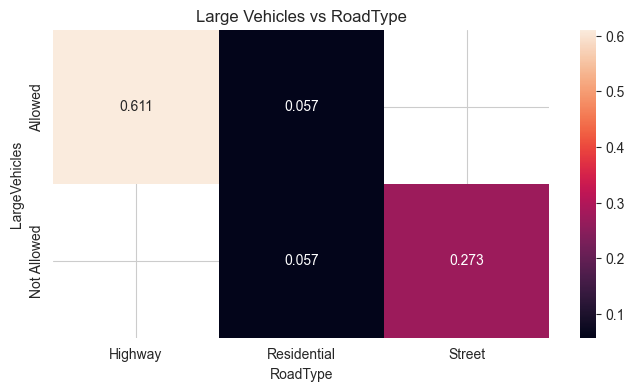

In [29]:
plt.figure(figsize=(8,4))

sns.heatmap(
    vehicle_road,
    annot=True,
    fmt=".3f"
)

plt.title(
    "Large Vehicles vs RoadType"
)

plt.show()

8. Demand Profile Clustering

In [30]:
profile = train.pivot_table(
    values="demand",
    index="geo5",
    columns="hour",
    aggfunc="mean"
)

profile.head()

hour,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23
geo5,,,,,,,,,,,,,,,,,,,,,,,,
qp02y,NaN,0.005397,0.017868,0.018810,0.018562,0.043532,0.042476,0.020455,0.022048,0.017647,0.048872,0.028569,0.025485,NaN,NaN,0.050364,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
qp02z,0.064790,0.082619,0.123837,0.146425,0.177247,0.157049,0.167250,0.160162,0.151250,0.160387,0.165976,0.192568,0.182894,0.173947,0.133869,0.119921,0.134136,0.087009,0.049009,0.036164,NaN,NaN,0.042385,0.054450
qp03j,0.019361,0.020424,0.026595,0.032327,0.030018,0.037435,0.038513,0.034811,0.032327,0.026800,0.029177,0.026947,0.025042,0.037738,0.026587,0.016551,0.012269,0.010678,0.003514,0.008594,0.009379,0.019359,0.029506,0.031317
qp03m,0.032798,0.032536,0.033050,0.036169,0.038005,0.056927,0.047420,0.056665,0.050879,0.053249,0.054282,0.057728,0.051665,0.058882,0.037827,0.023516,0.012104,0.009694,0.007409,0.009718,0.017353,0.030876,0.044459,0.048225
qp03n,0.060204,0.060968,0.063627,0.062445,0.070039,0.086471,0.075471,0.074495,0.079509,0.081090,0.072158,0.080249,0.092214,0.098111,0.073666,0.047523,0.031665,0.019191,0.010710,0.014334,0.011620,0.049148,0.073331,0.092854


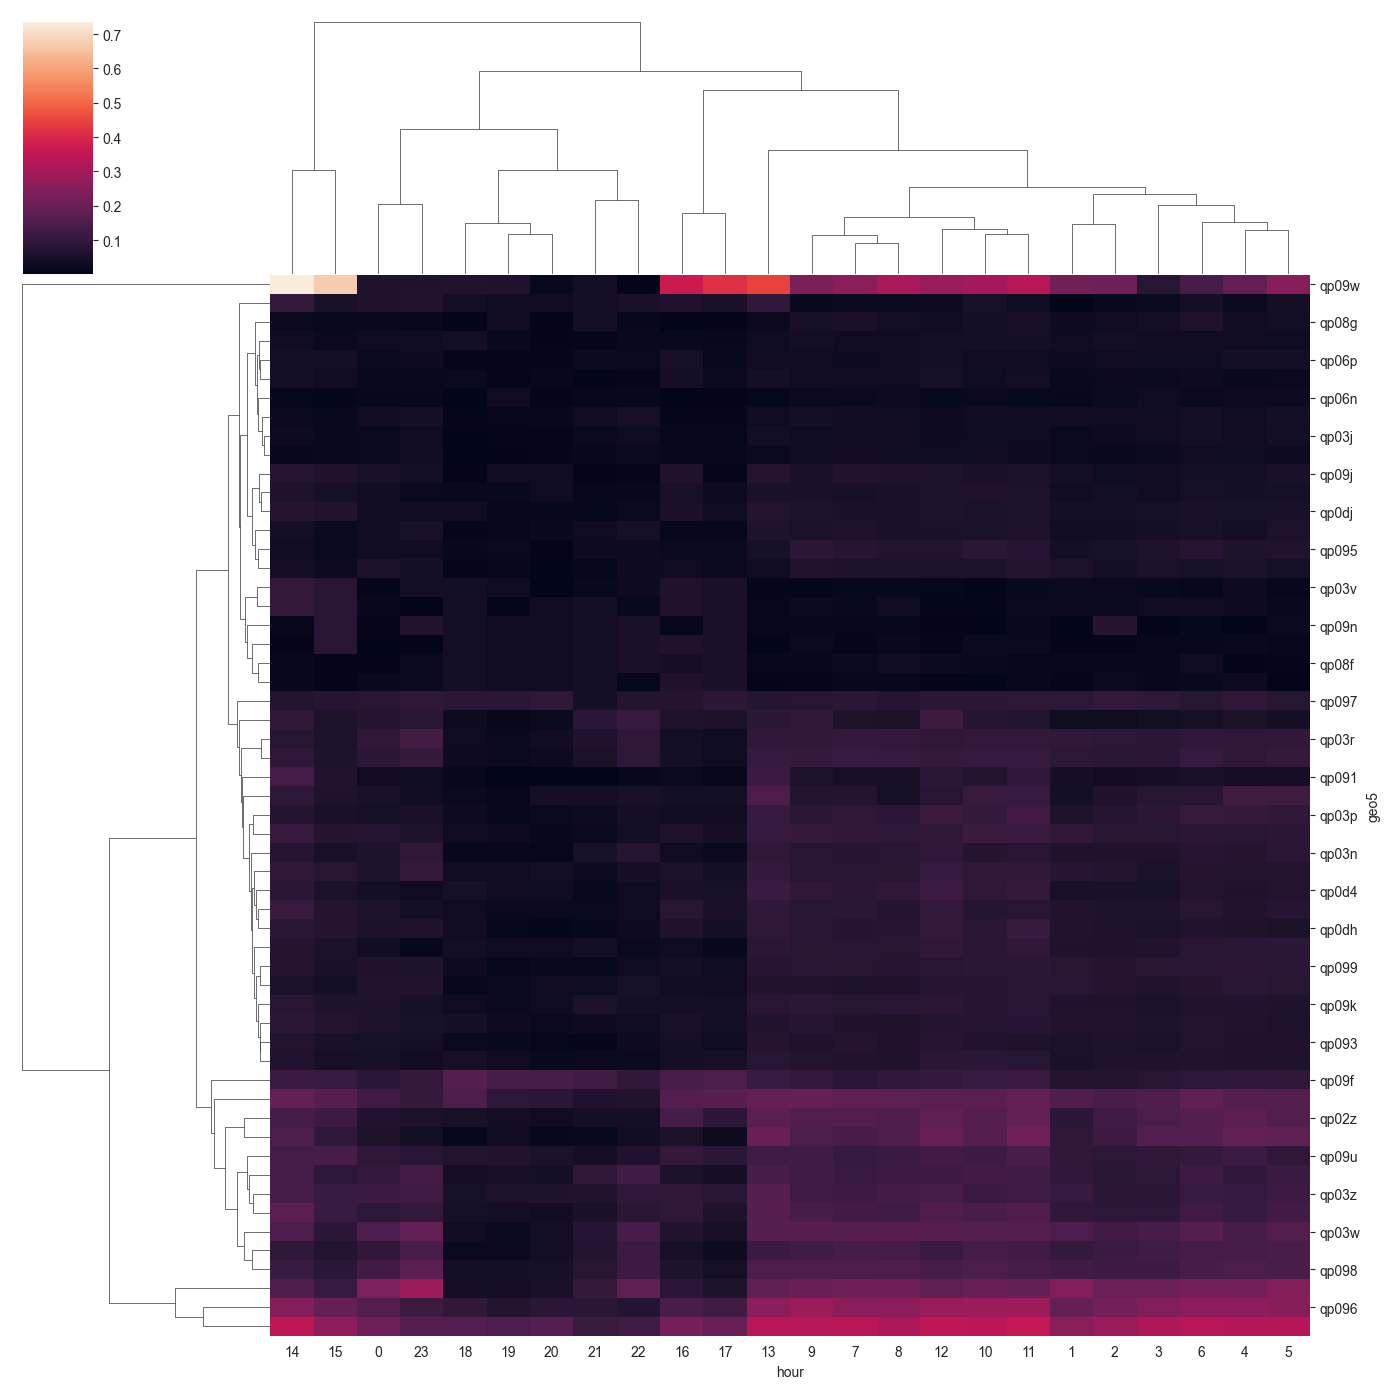

In [31]:
sns.clustermap(
    profile.fillna(
        profile.mean()
    ),
    figsize=(14,14)
)